# **Sentiment Analysis** - IMDB Dataset

Contains next sections:
- **Section 1:** Imports
- **Section 2:** Loading and preparing data
- **Section 3:** Split data
- **Section 4:** Algorithm 1
- **Section 5:** Algorithm 2
- **Section 6:** PCA analysis
- **Section 7:** Final testing on an independent test set
- **Section 8:** Data visualization
- **Section 9:** Final results and saving the model

## **Section 1:** Imports

In [1]:
%pip install tensorflow

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.1.1 -> 25.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import SVC
from sklearn.decomposition import PCA
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score, 
                           classification_report, confusion_matrix, roc_curve, auc)

from sklearn.preprocessing import StandardScaler
import joblib
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, LSTM, Embedding
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from nltk import FreqDist
import matplotlib.pyplot as plt
import seaborn as sns
import utils  # tvoj utils modul

from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.preprocessing import label_binarize
import re
import warnings
warnings.filterwarnings('ignore')

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\iam0v\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\iam0v\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     C:\Users\iam0v\AppData\Roaming\nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


In [19]:
from sklearn.svm import LinearSVC
from sklearn.calibration import CalibratedClassifierCV
from sklearn.model_selection import cross_val_score

## **Section 2:** Loading and preparing data

In [3]:
print("="*50)
print("SENTIMENT ANALYSIS - IMDB Dataset")
print("="*50)

# Učitavanje podataka
texts = []
labels = []
directory = r"C:\Users\iam0v\Downloads\datasets\imdb\train\pos"
utils.load_data(directory, texts, labels)
directory = r"C:\Users\iam0v\Downloads\datasets\imdb\train\neg"
utils.load_data(directory, texts, labels)
directory = r"C:\Users\iam0v\Downloads\datasets\imdb\test\pos"
utils.load_data(directory, texts, labels)
directory = r"C:\Users\iam0v\Downloads\datasets\imdb\test\neg"
utils.load_data(directory, texts, labels)

# Preprocesiranje
texts = [utils.lemmatize(utils.remove_stopwords(utils.remove_breaklines(text))) for text in texts]
texts = [utils.clean_text(text) for text in texts]

print(f"Ukupno tekstova: {len(texts)}")
print(f"Ukupno labela: {len(labels)}")

SENTIMENT ANALYSIS - IMDB Dataset
Ukupno tekstova: 50000
Ukupno labela: 50000


## **Section 3:** Split data

In [4]:
# VAŽNO: Izdvajanje finalnog test skupa (15%) koji se ne koristi do kraja
X_temp, X_final_test, y_temp, y_final_test = train_test_split(
    texts, labels, test_size=0.15, random_state=42, stratify=labels
)

# Podela preostalog na train i validation
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.2, random_state=42, stratify=y_temp
)

print(f"Train set: {len(X_train)} samples")
print(f"Validation set: {len(X_val)} samples")
print(f"Final test set: {len(X_final_test)} samples (izdvojen za finalno testiranje)")

Train set: 34000 samples
Validation set: 8500 samples
Final test set: 7500 samples (izdvojen za finalno testiranje)


## **Section 4:** Algorithm 1

In [5]:
print("\n--- Algoritam 1: LSTM ---")

# Priprema tokenizera
fdist = FreqDist()
for text in X_train:
    for word in text.split():
        fdist[word.lower()] += 1

num_of_words = len([word for word in fdist if fdist[word] > 3])
print(f"Broj reči u rečniku: {num_of_words}")

tokenizer_lstm = Tokenizer(num_words=num_of_words,
                          filters='!"#$%&()*+,-./:;<=>?@[\\]^_`{|}~\t\n',
                          lower=True,
                          split=' ')
tokenizer_lstm.fit_on_texts(X_train)


--- Algoritam 1: LSTM ---
Broj reči u rečniku: 33949


In [6]:
# Sekvence
X_train_seq = tokenizer_lstm.texts_to_sequences(X_train)
X_val_seq = tokenizer_lstm.texts_to_sequences(X_val)
X_final_seq = tokenizer_lstm.texts_to_sequences(X_final_test)

# Padding
seq_lengths = [len(text.split()) for text in X_train]
max_length = max(seq_lengths)
print(f"Maksimalna dužina sekvence: {max_length}")

X_train_seq = pad_sequences(X_train_seq, max_length)
X_val_seq = pad_sequences(X_val_seq, max_length)
X_final_seq = pad_sequences(X_final_seq, max_length)

print(f"Shape training sekvenci: {X_train_seq.shape}")

Maksimalna dužina sekvence: 1545
Shape training sekvenci: (34000, 1545)


In [7]:
# Funkcija za kreiranje LSTM modela sa različitim hiperparametrima
def create_lstm_model(lstm_units1=32, lstm_units2=16, embedding_dim=10):
    model = Sequential()
    model.add(Embedding(num_of_words, embedding_dim))
    model.add(LSTM(lstm_units1, return_sequences=True))
    model.add(LSTM(lstm_units2))
    model.add(Dense(1, activation='sigmoid'))
    model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
    return model

# Kreiranje i treniranje najbolje LSTM konfiguracije
print("Treniranje LSTM modela...")
best_lstm = create_lstm_model(32, 16, 10)

# Callback funkcije
early_stopping = EarlyStopping(monitor='val_loss', patience=4, mode='min', verbose=1)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=2, min_lr=0.001, mode='min', verbose=1)
checkpoint = ModelCheckpoint('sentiment_lstm_model.keras', monitor='val_loss', mode='min', save_best_only=True, verbose=1)

# Treniranje
history_lstm = best_lstm.fit(X_train_seq, np.array(y_train), 
                            epochs=10, batch_size=64, 
                            validation_data=(X_val_seq, np.array(y_val)),
                            callbacks=[early_stopping, reduce_lr, checkpoint],
                            verbose=1)

Treniranje LSTM modela...
Epoch 1/10
532/532 ━━━━━━━━━━━━━━━━━━━━ 0s 487ms/step - accuracy: 0.7248 - loss: 0.5302
Epoch 1: val_loss improved from None to 0.31468, saving model to sentiment_lstm_model.keras
532/532 ━━━━━━━━━━━━━━━━━━━━ 278s 518ms/step - accuracy: 0.8068 - loss: 0.4285 - val_accuracy: 0.8701 - val_loss: 0.3147 - learning_rate: 0.0010
Epoch 2/10
532/532 ━━━━━━━━━━━━━━━━━━━━ 0s 444ms/step - accuracy: 0.9193 - loss: 0.2231
Epoch 2: val_loss improved from 0.31468 to 0.28320, saving model to sentiment_lstm_model.keras
532/532 ━━━━━━━━━━━━━━━━━━━━ 251s 472ms/step - accuracy: 0.9163 - loss: 0.2243 - val_accuracy: 0.8796 - val_loss: 0.2832 - learning_rate: 0.0010
Epoch 3/10
532/532 ━━━━━━━━━━━━━━━━━━━━ 0s 445ms/step - accuracy: 0.9530 - loss: 0.1424
Epoch 3: val_loss did not improve from 0.28320
532/532 ━━━━━━━━━━━━━━━━━━━━ 251s 472ms/step - accuracy: 0.9481 - loss: 0.1495 - val_accuracy: 0.8769 - val_loss: 0.3339 - learning_rate: 0.0010
Epoch 4/10
532/532 ━━━━━━━━━━━━━━━━━━━━ 0

In [8]:
# Evaluacija LSTM na validation setu
print("\n--- LSTM Evaluacija na Validation Setu ---")
lstm_val_pred_prob = best_lstm.predict(X_val_seq)
lstm_val_pred = (lstm_val_pred_prob > 0.5).astype(int).flatten()

lstm_val_acc = accuracy_score(y_val, lstm_val_pred)
lstm_val_prec = precision_score(y_val, lstm_val_pred)
lstm_val_rec = recall_score(y_val, lstm_val_pred)
lstm_val_f1 = f1_score(y_val, lstm_val_pred)

print(f"LSTM Validation rezultati:")
print(f"Accuracy: {lstm_val_acc:.4f}")
print(f"Precision: {lstm_val_prec:.4f}")
print(f"Recall: {lstm_val_rec:.4f}")
print(f"F1-score: {lstm_val_f1:.4f}")

# Classification report
print("\nDetaljni Classification Report za LSTM:")
print(classification_report(y_val, lstm_val_pred, target_names=['Negative', 'Positive']))


--- LSTM Evaluacija na Validation Setu ---
266/266 ━━━━━━━━━━━━━━━━━━━━ 21s 78ms/step
LSTM Validation rezultati:
Accuracy: 0.8704
Precision: 0.8929
Recall: 0.8416
F1-score: 0.8665

Detaljni Classification Report za LSTM:
              precision    recall  f1-score   support

    Negative       0.85      0.90      0.87      4250
    Positive       0.89      0.84      0.87      4250

    accuracy                           0.87      8500
   macro avg       0.87      0.87      0.87      8500
weighted avg       0.87      0.87      0.87      8500



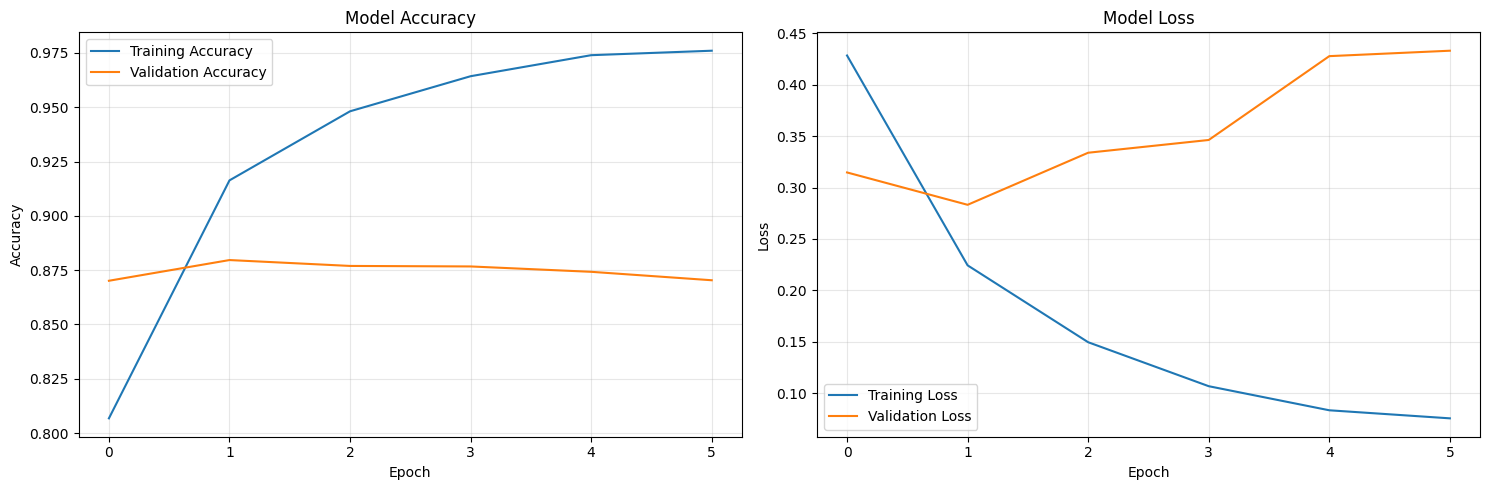

Najbolja validation accuracy: 0.8796
Finalna validation loss: 0.4331


In [10]:
# Vizualizacija training history
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Accuracy
axes[0].plot(history_lstm.history['accuracy'], label='Training Accuracy')
axes[0].plot(history_lstm.history['val_accuracy'], label='Validation Accuracy')
axes[0].set_title('Model Accuracy')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Loss
axes[1].plot(history_lstm.history['loss'], label='Training Loss')
axes[1].plot(history_lstm.history['val_loss'], label='Validation Loss')
axes[1].set_title('Model Loss')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('lstm_training_history.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"Najbolja validation accuracy: {max(history_lstm.history['val_accuracy']):.4f}")
print(f"Finalna validation loss: {history_lstm.history['val_loss'][-1]:.4f}")

## **Section 5:** Algorithm 2

In [11]:
print("\n--- Algoritam 2: SVM sa TF-IDF ---")

# TF-IDF vektorizacija - optimizovana
tfidf_sentiment = TfidfVectorizer(max_features=1000, stop_words='english', max_df=0.7, min_df=5, ngram_range=(1, 1))
X_train_tfidf = tfidf_sentiment.fit_transform(X_train)
X_val_tfidf = tfidf_sentiment.transform(X_val)
X_final_tfidf = tfidf_sentiment.transform(X_final_test)

print(f"TF-IDF shape: {X_train_tfidf.shape}")


--- Algoritam 2: SVM sa TF-IDF ---
TF-IDF shape: (34000, 1000)


In [13]:
# LinearSVC je MNOGO brži za linearne kernele
print("Grid Search za LinearSVC...")
param_grid_linear = {
    'C': [0.1, 1, 10]
}

linear_svc = LinearSVC(random_state=42, max_iter=1000)
grid_search_svm = GridSearchCV(linear_svc, param_grid_linear, 
                               cv=3, scoring='f1', n_jobs=-1, verbose=1)
grid_search_svm.fit(X_train_tfidf, y_train)

# Ako treba probability, wrap sa CalibratedClassifierCV
best_svm = CalibratedClassifierCV(grid_search_svm.best_estimator_)
best_svm.fit(X_train_tfidf, y_train)

Grid Search za LinearSVC...
Fitting 3 folds for each of 3 candidates, totalling 9 fits


,estimator,LinearSVC(C=0...ndom_state=42)
,method,'sigmoid'
,cv,None
,n_jobs,None
,ensemble,'auto'
,penalty,'l2'
,loss,'squared_hinge'
,dual,'auto'
,tol,0.0001
,C,0.1
,multi_class,'ovr'


In [16]:
# Evaluacija SVM na validation setu
print("\n--- SVM Evaluacija na Validation Setu ---")
svm_val_pred = best_svm.predict(X_val_tfidf)

svm_val_acc = accuracy_score(y_val, svm_val_pred)
svm_val_prec = precision_score(y_val, svm_val_pred)
svm_val_rec = recall_score(y_val, svm_val_pred)
svm_val_f1 = f1_score(y_val, svm_val_pred)

print(f"SVM Validation rezultati:")
print(f"Accuracy: {svm_val_acc:.4f}")
print(f"Precision: {svm_val_prec:.4f}")
print(f"Recall: {svm_val_rec:.4f}")
print(f"F1-score: {svm_val_f1:.4f}")

# Classification report
print("\nDetaljni Classification Report za SVM:")
print(classification_report(y_val, svm_val_pred, target_names=['Negative', 'Positive']))

# Feature importance za linearni SVM
# Uzmi underlying estimator iz calibrated_classifiers_
base_model = best_svm.calibrated_classifiers_[0].estimator

# Proveravamo da li je LinearSVC (koji je uvek linearan)
if hasattr(base_model, 'coef_'):
    feature_names = tfidf_sentiment.get_feature_names_out()
    coefficients = base_model.coef_[0]
    
    # Top pozitivne reči (za pozitivni sentiment)
    pos_indices = coefficients.argsort()[-10:][::-1]
    print(f"\nTop 10 reči za POZITIVNI sentiment:")
    for i, idx in enumerate(pos_indices):
        print(f"{i+1}. {feature_names[idx]}: {coefficients[idx]:.4f}")
    
    # Top negativne reči (za negativni sentiment) 
    neg_indices = coefficients.argsort()[:10]
    print(f"\nTop 10 reči za NEGATIVNI sentiment:")
    for i, idx in enumerate(neg_indices):
        print(f"{i+1}. {feature_names[idx]}: {coefficients[idx]:.4f}")
else:
    print("\nModel nema linearnih koeficijenata za prikaz feature importance.")


--- SVM Evaluacija na Validation Setu ---
SVM Validation rezultati:
Accuracy: 0.8612
Precision: 0.8503
Recall: 0.8767
F1-score: 0.8633

Detaljni Classification Report za SVM:
              precision    recall  f1-score   support

    Negative       0.87      0.85      0.86      4250
    Positive       0.85      0.88      0.86      4250

    accuracy                           0.86      8500
   macro avg       0.86      0.86      0.86      8500
weighted avg       0.86      0.86      0.86      8500


Top 10 reči za POZITIVNI sentiment:
1. excellent: 2.0336
2. great: 1.9498
3. best: 1.5098
4. superb: 1.4582
5. favorite: 1.4244
6. perfect: 1.3894
7. wonderful: 1.3874
8. illiant: 1.3254
9. amaze: 1.3170
10. fantastic: 1.2781

Top 10 reči za NEGATIVNI sentiment:
1. worst: -2.9939
2. waste: -2.8059
3. awful: -2.5129
4. bad: -2.1572
5. bore: -1.8634
6. poor: -1.8450
7. dull: -1.7611
8. poorly: -1.7395
9. terrible: -1.7024
10. fail: -1.6712


## **Section 6:** PCA analysis

In [18]:
print("\n--- Optimizovana PCA na TF-IDF features ---")

# Standardizacija pre PCA (važno za PCA)
scaler = StandardScaler(with_mean=False)  # with_mean=False jer je sparse matrix
X_train_scaled = scaler.fit_transform(X_train_tfidf)
X_val_scaled = scaler.transform(X_val_tfidf)

# Optimizovana PCA sa manjim brojem komponenti za brzinu
pca = PCA(n_components=100, random_state=42)  # Fiksiran broj umesto 95% varijanse
X_train_pca = pca.fit_transform(X_train_scaled.toarray())
X_val_pca = pca.transform(X_val_scaled.toarray())

print(f"Originalna dimenzionalnost: {X_train_tfidf.shape[1]}")
print(f"PCA dimenzionalnost: {X_train_pca.shape[1]}")
print(f"Objašnjena varijansa: {pca.explained_variance_ratio_.sum():.4f}")


--- Optimizovana PCA na TF-IDF features ---
Originalna dimenzionalnost: 1000
PCA dimenzionalnost: 100
Objašnjena varijansa: 0.1628


In [20]:
# Model bez PCA (već treniran)
scores_without_pca = cross_val_score(best_svm, X_val_tfidf, y_val, cv=3, scoring='f1')

# Model sa PCA
simple_svm_pca = LinearSVC(C=1.0, random_state=42)
simple_svm_pca.fit(X_train_pca, y_train)
scores_with_pca = cross_val_score(simple_svm_pca, X_val_pca, y_val, cv=3, scoring='f1')

print(f"F1 score bez PCA: {scores_without_pca.mean():.4f}")
print(f"F1 score sa PCA: {scores_with_pca.mean():.4f}")

if scores_without_pca.mean() > scores_with_pca.mean():
    print("SVM radi bolje BEZ PCA redukcije")
    final_svm_sentiment = best_svm
    use_pca_svm = False
else:
    print("SVM radi bolje SA PCA redukcijom")
    final_svm_sentiment = CalibratedClassifierCV(simple_svm_pca)
    final_svm_sentiment.fit(X_train_pca, y_train)
    use_pca_svm = True

F1 score bez PCA: 0.8445
F1 score sa PCA: 0.8505
SVM radi bolje SA PCA redukcijom


## **Section 7:** Final testing on an independent test set

In [21]:
print("\n" + "="*50)
print("FINALNO TESTIRANJE NA NEZAVISNOM TEST SKUPU")
print("="*50)

print("\n--- SENTIMENT ANALYSIS ---")

# Kombinuj train i validation za finalno treniranje
X_full_train = X_train + X_val
y_full_train = y_train + y_val

print(f"Finalni training set: {len(X_full_train)} samples")


FINALNO TESTIRANJE NA NEZAVISNOM TEST SKUPU

--- SENTIMENT ANALYSIS ---
Finalni training set: 42500 samples


In [23]:
# 1. LSTM - retreniranje na celom skupu
tokenizer_final = Tokenizer(num_words=num_of_words,
                           filters='!"#$%&()*+,-./:;<=>?@[\\]^_`{|}~\t\n',
                           lower=True, split=' ')
tokenizer_final.fit_on_texts(X_full_train)

X_full_seq = tokenizer_final.texts_to_sequences(X_full_train)
X_test_seq_final = tokenizer_final.texts_to_sequences(X_final_test)

X_full_seq = pad_sequences(X_full_seq, max_length)
X_test_seq_final = pad_sequences(X_test_seq_final, max_length)

final_lstm = create_lstm_model(32, 16, 10)
final_lstm.fit(X_full_seq, np.array(y_full_train), epochs=5, batch_size=128, verbose=0)

# Predikcije i mere za LSTM
lstm_pred = (final_lstm.predict(X_test_seq_final) > 0.5).astype(int).flatten()
lstm_acc = accuracy_score(y_final_test, lstm_pred)
lstm_prec = precision_score(y_final_test, lstm_pred)
lstm_rec = recall_score(y_final_test, lstm_pred)
lstm_f1 = f1_score(y_final_test, lstm_pred)

print(f"\nLSTM rezultati:")
print(f"Accuracy: {lstm_acc:.4f}")
print(f"Precision: {lstm_prec:.4f}")
print(f"Recall: {lstm_rec:.4f}")
print(f"F1-score: {lstm_f1:.4f}")

235/235 ━━━━━━━━━━━━━━━━━━━━ 28s 118ms/step

LSTM rezultati:
Accuracy: 0.8792
Precision: 0.8543
Recall: 0.9144
F1-score: 0.8833


In [24]:
# 2. SVM - finalno treniranje
X_full_tfidf = tfidf_sentiment.fit_transform(X_full_train)
X_test_tfidf_final = tfidf_sentiment.transform(X_final_test)

if use_pca_svm:
    X_full_scaled = scaler.fit_transform(X_full_tfidf)
    X_test_scaled = scaler.transform(X_test_tfidf_final)
    X_full_pca = pca.fit_transform(X_full_scaled.toarray())
    X_test_pca = pca.transform(X_test_scaled.toarray())
    final_svm_sentiment.fit(X_full_pca, y_full_train)
    svm_pred = final_svm_sentiment.predict(X_test_pca)
else:
    final_svm_sentiment.fit(X_full_tfidf, y_full_train)
    svm_pred = final_svm_sentiment.predict(X_test_tfidf_final)

svm_acc = accuracy_score(y_final_test, svm_pred)
svm_prec = precision_score(y_final_test, svm_pred)
svm_rec = recall_score(y_final_test, svm_pred)
svm_f1 = f1_score(y_final_test, svm_pred)

print(f"\nSVM rezultati:")
print(f"Accuracy: {svm_acc:.4f}")
print(f"Precision: {svm_prec:.4f}")
print(f"Recall: {svm_rec:.4f}")
print(f"F1-score: {svm_f1:.4f}")


SVM rezultati:
Accuracy: 0.8585
Precision: 0.8491
Recall: 0.8720
F1-score: 0.8604


## **Section 8:** Data visualization


--- Generisanje vizualizacija ---


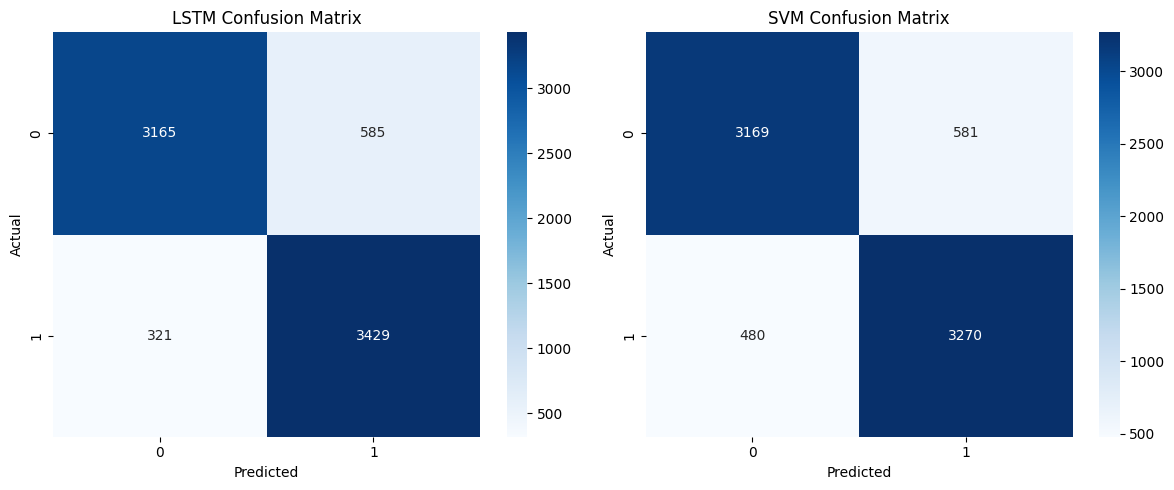

In [25]:
print("\n--- Generisanje vizualizacija ---")

# Confusion Matrix za sentiment analizu
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

cm_lstm = confusion_matrix(y_final_test, lstm_pred)
sns.heatmap(cm_lstm, annot=True, fmt='d', ax=axes[0], cmap='Blues')
axes[0].set_title('LSTM Confusion Matrix')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')

cm_svm = confusion_matrix(y_final_test, svm_pred)
sns.heatmap(cm_svm, annot=True, fmt='d', ax=axes[1], cmap='Blues')
axes[1].set_title('SVM Confusion Matrix')
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('Actual')

plt.tight_layout()
plt.savefig('segmentation_confusion_matrices.png')
plt.show()

235/235 ━━━━━━━━━━━━━━━━━━━━ 26s 110ms/step


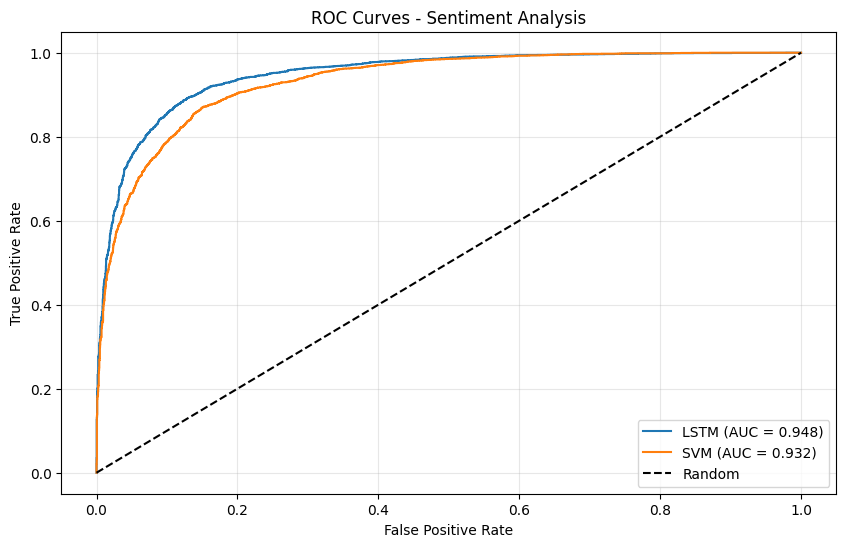

In [26]:
# ROC krive za sentiment analizu
plt.figure(figsize=(10, 6))

# LSTM ROC
lstm_proba = final_lstm.predict(X_test_seq_final).flatten()
fpr_lstm, tpr_lstm, _ = roc_curve(y_final_test, lstm_proba)
roc_auc_lstm = auc(fpr_lstm, tpr_lstm)

# SVM ROC
svm_proba = final_svm_sentiment.predict_proba(X_test_tfidf_final if not use_pca_svm else X_test_pca)[:, 1]
fpr_svm, tpr_svm, _ = roc_curve(y_final_test, svm_proba)
roc_auc_svm = auc(fpr_svm, tpr_svm)

plt.plot(fpr_lstm, tpr_lstm, label=f'LSTM (AUC = {roc_auc_lstm:.3f})')
plt.plot(fpr_svm, tpr_svm, label=f'SVM (AUC = {roc_auc_svm:.3f})')
plt.plot([0, 1], [0, 1], 'k--', label='Random')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves - Sentiment Analysis')
plt.legend()
plt.grid(True, alpha=0.3)
plt.savefig('roc_curves_sentiment.png')
plt.show()

## **Section 9:** Final results and saving the model

In [27]:
# Poređenje algoritama za sentiment analizu
results_df = pd.DataFrame({
    'Algorithm': ['LSTM', 'SVM'],
    'Accuracy': [lstm_acc, svm_acc],
    'Precision': [lstm_prec, svm_prec],
    'Recall': [lstm_rec, svm_rec],
    'F1-score': [lstm_f1, svm_f1],
    'Dimensionality Reduction': ['None', 'PCA' if use_pca_svm else 'None']
})

print("\n" + "="*50)
print("FINALNI REZULTATI - SENTIMENT ANALYSIS")
print("="*50)
print(results_df.to_string(index=False))


FINALNI REZULTATI - SENTIMENT ANALYSIS
Algorithm  Accuracy  Precision  Recall  F1-score Dimensionality Reduction
     LSTM  0.879200    0.85426  0.9144  0.883308                     None
      SVM  0.858533    0.84913  0.8720  0.860413                      PCA


In [29]:
print("\n--- Čuvanje modela ---")
joblib.dump(final_svm_sentiment, 'final_svm_sentiment_model.pkl')
joblib.dump(tfidf_sentiment, 'tfidf_sentiment_vectorizer.pkl')
joblib.dump(pca, 'pca_transformer.pkl')
final_lstm.save("final_lstm_sentiment_model.keras")

print("Svi sentiment analysis modeli su sačuvani!")
print("- final_svm_sentiment_model.pkl")
print("- tfidf_sentiment_vectorizer.pkl") 
print("- pca_transformer.pkl")
print("- final_lstm_sentiment_model.h5")


--- Čuvanje modela ---
Svi sentiment analysis modeli su sačuvani!
- final_svm_sentiment_model.pkl
- tfidf_sentiment_vectorizer.pkl
- pca_transformer.pkl
- final_lstm_sentiment_model.h5
